<a href="https://colab.research.google.com/github/Ayush-Agrawalcs/ML_review_Wk_9/blob/main/Machine_Learning_Review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn scipy joblib

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score,precision_score, roc_auc_score,recall_score,f1_score,confusion_matrix,ConfusionMatrixDisplay,classification_report,RocCurveDisplay)
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)
from sklearn.neighbors import NearestNeighbors
import pandas as pd
from scipy.io import arff
import joblib
import json
from pathlib import Path

In [ ]:
data, meta = arff.loadarff('/content/file1730492b4408.arff')

df = pd.DataFrame(data)

### Engineer 1 - Ayush Singh
### Engineer 2 - Shreyash Singh
### Engineer 3 - Ayush Agrawal
### Engineer 4 - Naman Vinay Singh (Essemble learning)


# Engineer 1 – Linear Regression

## Business Scenario
A Supply Chain Manager wants to forecast future product prices using historical supply-chain indicators.

---

## Tasks

### 1. Model Building
Build and evaluate the following models:

- Linear Regression
- Ridge Regression
- Lasso Regression

### 2. Feature Engineering
- Create a feature importance ranking.
- Identify and remove multicollinearity (if required).
- Compare the performance of all models.

---

## Evaluation Metrics

Evaluate each model using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

---

## Visualizations

Create the following visualizations:

1. Actual vs Predicted Plot
2. Residual Plot
3. Feature Importance Plot

---

## Deliverables

Provide the following:

### Best Performing Model
- Identify the model with the best overall performance based on evaluation metrics.

### Top 5 Important Features
- List and explain the five most influential features affecting product price prediction.

### Business Recommendations
- Provide actionable insights and recommendations based on the model results and feature importance analysis.


In [ ]:
df02 = df.copy()
df02.head()





,timeunit,storageCost,interestRate,compidx0lt2,compidx4lt2,compidx6lt2,compidx8lt2,compidx10lt2,compidx12lt2,compidx14lt2,...,MTLp7A,MTLp8A,MTLp9A,MTLp10A,MTLp11A,MTLp12A,MTLp13A,MTLp14A,MTLp15A,MTLp16A
0,9.0,27.0,8.0,881.606,276.589,283.096,113.193,108.831,247.377,228.541,...,1747.0,1905.0,1414.0,1336.0,1409.0,1535.0,1795.0,1871.0,1783.0,1649.0
1,10.0,27.0,8.0,869.455,288.277,271.252,116.232,109.822,250.485,222.397,...,1794.0,2060.0,1270.0,1404.0,1405.0,1486.0,1786.0,2077.0,1803.0,1650.0
2,11.0,27.0,8.0,850.916,288.429,271.573,116.703,108.636,252.319,218.822,...,1774.0,1876.0,1397.0,1444.0,1400.0,1505.0,1871.0,2050.0,1751.0,1653.0
3,12.0,27.0,8.0,862.066,290.866,268.637,117.098,109.253,257.071,204.266,...,1760.0,1820.0,1315.0,1477.0,1419.0,1546.0,1833.0,2070.0,1798.0,1645.0
4,13.0,27.0,8.0,842.781,278.185,270.078,116.822,105.997,257.858,213.514,...,1780.0,1846.0,1435.0,1412.0,1305.0,1455.0,1847.0,2024.0,1775.0,1646.0


In [ ]:
df02.describe()

df02.info()

df['LBL'].describe()

df['LBL'].head()

X = df02.drop('LBL', axis=1)
y = df02['LBL']

print(X.shape)
print(y.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8966 entries, 0 to 8965
Data columns (total 77 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timeunit       8966 non-null   float64
 1   storageCost    8966 non-null   float64
 2   interestRate   8966 non-null   float64
 3   compidx0lt2    8966 non-null   float64
 4   compidx4lt2    8966 non-null   float64
 5   compidx6lt2    8966 non-null   float64
 6   compidx8lt2    8966 non-null   float64
 7   compidx10lt2   8966 non-null   float64
 8   compidx12lt2   8966 non-null   float64
 9   compidx14lt2   8966 non-null   float64
 10  compidx0lt6    8966 non-null   float64
 11  compidx4lt6    8966 non-null   float64
 12  compidx6lt6    8966 non-null   float64
 13  compidx8lt6    8966 non-null   float64
 14  compidx10lt6   8966 non-null   float64
 15  compidx12lt6   8966 non-null   float64
 16  compidx14lt6   8966 non-null   float64
 17  compidx0lt10   8966 non-null   float64
 18  compidx4

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:

import numpy as np

corr_matrix = X_train.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [
    column
    for column in upper.columns
    if any(upper[column] > 0.90)
]

print("Columns to remove:")
print(to_drop)

X_train_mc = X_train.drop(columns=to_drop)
X_test_mc = X_test.drop(columns=to_drop)

print(X_train_mc.shape)

Columns to remove:
['compidx0lt6', 'compidx6lt6', 'compidx8lt6', 'compidx10lt6', 'compidx14lt6', 'compidx0lt10', 'compidx4lt10', 'compidx6lt10', 'compidx8lt10', 'compidx10lt10', 'compidx12lt10', 'compidx14lt10', 'compidx0lt20', 'compidx4lt20', 'compidx6lt20', 'compidx8lt20', 'compidx10lt20', 'compidx12lt20', 'compidx14lt20', 'compidx0lt30', 'compidx4lt30', 'compidx6lt30', 'compidx8lt30', 'compidx10lt30', 'compidx12lt30', 'compidx14lt30', 'sku16', 'demandseg1l1', 'demandseg1l2', 'demandseg1l4', 'demandseg1l8', 'demandseg2l1', 'demandseg2l2', 'demandseg2l4', 'demandseg2l8', 'demandseg3l1', 'demandseg3l2', 'demandseg3l4', 'demandseg3l8', 'MTLp4A', 'MTLp8A', 'MTLp16A']
(7172, 34)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_mc)
X_test_scaled = scaler.transform(X_test_mc)

from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)



from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)


from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)

lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

def evaluate_model(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    mse = mean_squared_error(y_true, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_true, y_pred)

    return mae, mse, rmse, r2

In [ ]:
results = []

models = {
    "Linear Regression": y_pred_lr,
    "Ridge Regression": y_pred_ridge,
    "Lasso Regression": y_pred_lasso
}

for name, pred in models.items():

    mae, mse, rmse, r2 = evaluate_model(y_test, pred)

    results.append([name, mae, mse, rmse, r2])

import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=["Model","MAE","MSE","RMSE","R2"]
)

print(results_df)

               Model        MAE          MSE       RMSE        R2
0  Linear Regression  41.405572  4523.362811  67.255950  0.908766
1   Ridge Regression  41.408128  4523.162444  67.254460  0.908770
2   Lasso Regression  41.371872  4528.675029  67.295431  0.908659


In [ ]:
results_df.sort_values(
    by='R2',
    ascending=False
)

,Model,MAE,MSE,RMSE,R2
1,Ridge Regression,41.408128,4523.162444,67.254460,0.908770
0,Linear Regression,41.405572,4523.362811,67.255950,0.908766
2,Lasso Regression,41.371872,4528.675029,67.295431,0.908659


In [ ]:
#feature Importance taken help
importance = pd.DataFrame({
    'Feature': X_train_mc.columns,
    'Coefficient': ridge.coef_
})

importance['Abs_Coefficient'] = abs(
    importance['Coefficient']
)

importance = importance.sort_values(
    by='Abs_Coefficient',
    ascending=False
)

importance.head(10)

,Feature,Coefficient,Abs_Coefficient
22,MTLp2A,108.064898,108.064898
23,MTLp3A,74.304301,74.304301
27,MTLp9A,33.481846,33.481846
30,MTLp12A,-29.314481,29.314481
31,MTLp13A,14.902333,14.902333
12,sku1,14.481171,14.481171
3,compidx0lt2,12.977700,12.977700
15,sku12,-10.737321,10.737321
11,compidx12lt6,9.819844,9.819844
7,compidx10lt2,8.913636,8.913636


In [ ]:
top5 = importance.head(5)

print(top5)

    Feature  Coefficient  Abs_Coefficient
22   MTLp2A   108.064898       108.064898
23   MTLp3A    74.304301        74.304301
27   MTLp9A    33.481846        33.481846
30  MTLp12A   -29.314481        29.314481
31  MTLp13A    14.902333        14.902333


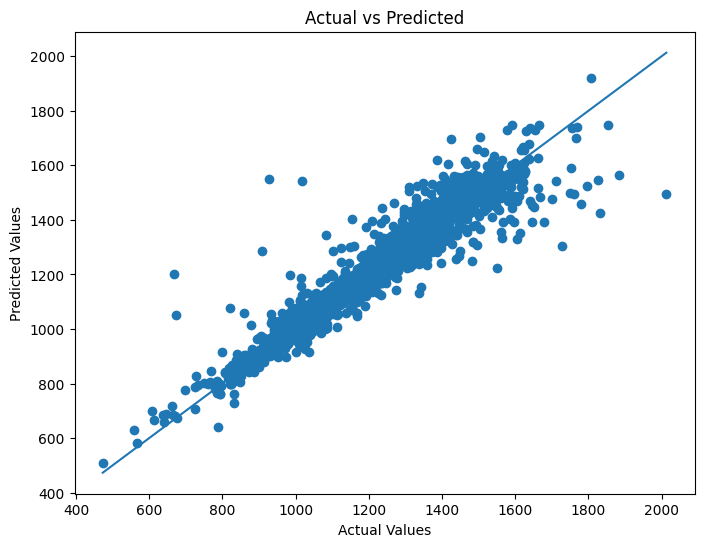

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_ridge)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()

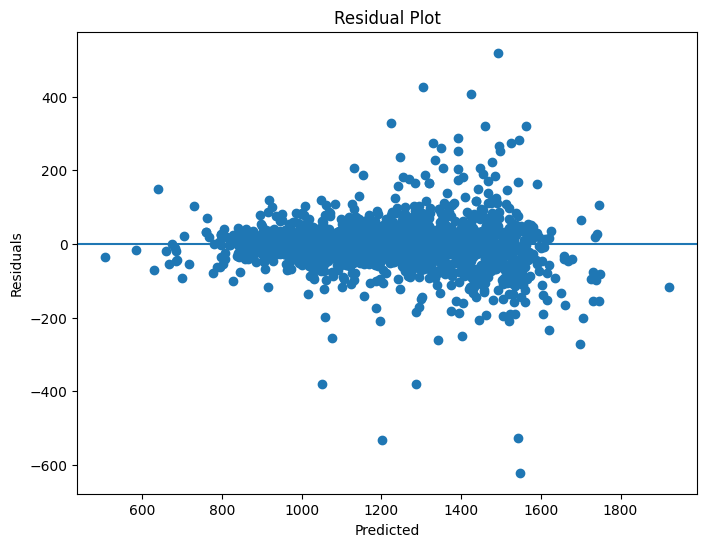

In [ ]:
residuals = y_test - y_pred_ridge

plt.figure(figsize=(8,6))

plt.scatter(y_pred_ridge, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

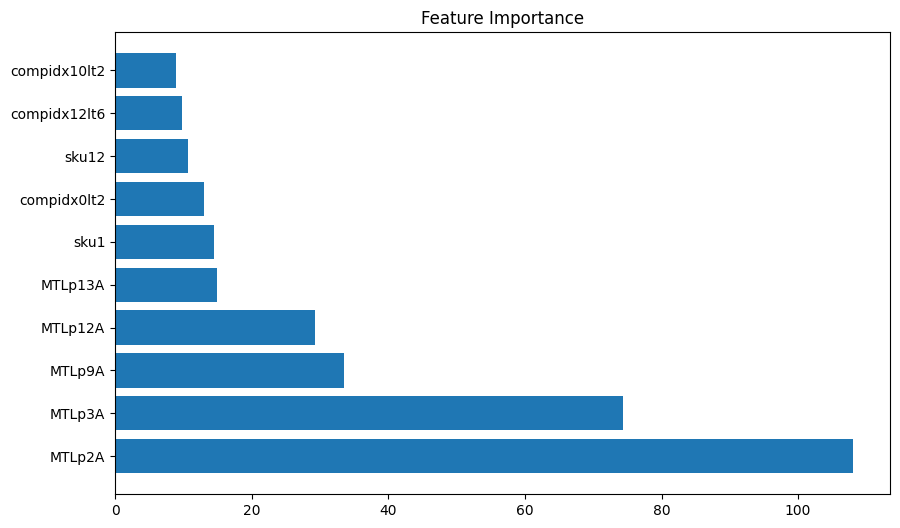

In [ ]:
top10 = importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10['Feature'],
    top10['Abs_Coefficient']
)

plt.title("Feature Importance")

plt.show()

# Engineer 2 – Logistic Regression

## Business Scenario
Management wants to classify whether a future product price movement will result in:

- High Growth
- Low Growth

---

## Target Engineering

Create a binary target variable based on the median price growth:

- **Above Median** → High Growth (1)
- **Below Median** → Low Growth (0)

---

## Tasks

### 1. Model Building

Build and evaluate a:

- Logistic Regression Model

### 2. Hyperparameter Tuning

Optimize model performance using:

- GridSearchCV

Potential parameters to tune:

- Regularization strength (`C`)
- Penalty (`l1`, `l2`)
- Solver (`liblinear`, `saga`)

---

## Evaluation Metrics

Evaluate the classification model using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC Score

---

## Visualizations

Create the following visualizations:

1. Confusion Matrix
2. ROC Curve
3. Feature Coefficient Analysis

---

## Deliverables

### Classification Report

Provide a detailed classification report including:

- Precision
- Recall
- F1 Score
- Support

### Most Influential Features

Identify and explain the features that most strongly influence the prediction of:

- High Growth
- Low Growth

### Business Insights

Provide actionable recommendations based on:

- Growth-driving factors
- Risk indicators
- Strategic pricing and supply-chain decisions


===== Logistic Regression Results =====
Accuracy : 0.9899665551839465
Precision : 0.9910313901345291
Recall : 0.9888143176733781
F1 Score : 0.9899216125419933
ROC AUC : 0.9997464578672632

===== Classification Report =====
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       900
           1       0.99      0.99      0.99       894

    accuracy                           0.99      1794
   macro avg       0.99      0.99      0.99      1794
weighted avg       0.99      0.99      0.99      1794


===== Tuned Model Results =====
Accuracy : 0.9988851727982163
Precision : 0.9977678571428571
Recall : 1.0
F1 Score : 0.9988826815642458
ROC AUC : 0.9988888888888888


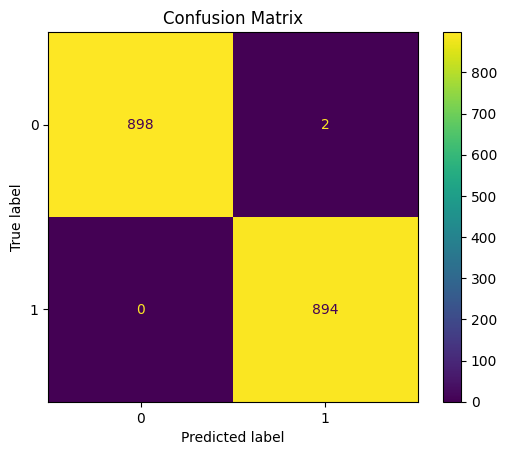

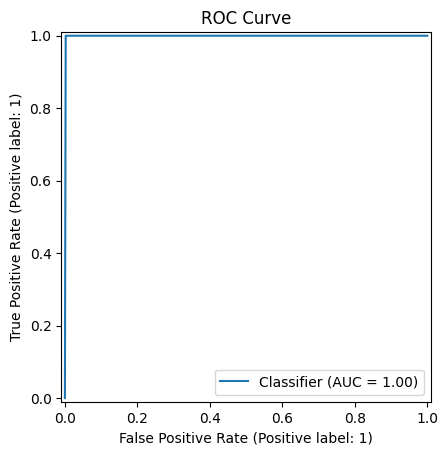

In [ ]:
df1=df.copy()
median_growth = df1["LBL"].median()
df1["target"] = np.where(
    df1["LBL"] > median_growth,
    1,
    0
)
X = df1.drop('target',axis=1)
y = df1["target"]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# FEATURE SCALING
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logistic_model = LogisticRegression()

logistic_model.fit(X_train_scaled, y_train)

y_pred = logistic_model.predict(X_test_scaled)
y_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("\n===== Logistic Regression Results =====")

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC :", roc_auc_score(y_test, y_prob))

print("\n===== Classification Report =====")

print(classification_report(y_test, y_pred))

# HYPERPARAMETER TUNING
param_grid = [
    {
        "solver": ["liblinear"],
        "penalty": ["l1", "l2"],
        "C": [0.01, 0.1, 1]
    },
    {
        "solver": ["saga"],
        "penalty": ["l1", "l2"],
        "C": [0.01, 0.1, 1]
    }
]

grid = GridSearchCV(
    logistic_model,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

y_pred = grid.predict(X_test_scaled)

print("\n===== Tuned Model Results =====")

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC :", roc_auc_score(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Confusion Matrix")
plt.show()

RocCurveDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("ROC Curve")
plt.show()




# Engineer 3 – KNN & SVM

## Business Scenario

Build intelligent machine learning models capable of identifying future market behavior based on similar supply-chain patterns.

---

# Part A: K-Nearest Neighbors (KNN) Classification

## Tasks

### 1. Data Preprocessing
- Apply feature scaling to all numerical features.
- Use an appropriate scaling technique such as:
  - StandardScaler
  - MinMaxScaler

### 2. Model Building
Train and evaluate KNN models using the following values of K:

- K = 3
- K = 5
- K = 7
- K = 9
- K = 11
- K = 13

### 3. Model Comparison
- Compare the performance of all K values.
- Identify the optimal K based on evaluation metrics.

---

## Evaluation Metrics

Evaluate each KNN model using:

- Accuracy
- Precision
- Recall
- F1 Score

---

## Visualizations

Create the following visualizations:

1. Error Rate vs K Value Plot
2. Accuracy vs K Value Plot
3. Confusion Matrix (for the best K)

---

## Deliverables

### Best K Value
- Identify the optimal K value based on model performance.

### Error Rate Analysis
- Analyze how error rates change with different K values.
- Explain the impact of underfitting and overfitting.

### Business Insights
- Explain how similarity-based learning can help identify future market behavior.

---

# Part B: Support Vector Machine (SVM)

## Tasks

### 1. Model Building

Train and evaluate SVM models using the following kernels:

- Linear Kernel
- Polynomial Kernel
- RBF (Radial Basis Function) Kernel

### 2. Hyperparameter Tuning

Perform hyperparameter optimization using GridSearchCV.

#### Parameter Grid

```python
{
    "C": [0.1, 1, 10],
    "gamma": ["scale", "auto"]
}

In [ ]:
df1=df.copy()
df1.head()

,timeunit,storageCost,interestRate,compidx0lt2,compidx4lt2,compidx6lt2,compidx8lt2,compidx10lt2,compidx12lt2,compidx14lt2,...,MTLp7A,MTLp8A,MTLp9A,MTLp10A,MTLp11A,MTLp12A,MTLp13A,MTLp14A,MTLp15A,MTLp16A
0,9.0,27.0,8.0,881.606,276.589,283.096,113.193,108.831,247.377,228.541,...,1747.0,1905.0,1414.0,1336.0,1409.0,1535.0,1795.0,1871.0,1783.0,1649.0
1,10.0,27.0,8.0,869.455,288.277,271.252,116.232,109.822,250.485,222.397,...,1794.0,2060.0,1270.0,1404.0,1405.0,1486.0,1786.0,2077.0,1803.0,1650.0
2,11.0,27.0,8.0,850.916,288.429,271.573,116.703,108.636,252.319,218.822,...,1774.0,1876.0,1397.0,1444.0,1400.0,1505.0,1871.0,2050.0,1751.0,1653.0
3,12.0,27.0,8.0,862.066,290.866,268.637,117.098,109.253,257.071,204.266,...,1760.0,1820.0,1315.0,1477.0,1419.0,1546.0,1833.0,2070.0,1798.0,1645.0
4,13.0,27.0,8.0,842.781,278.185,270.078,116.822,105.997,257.858,213.514,...,1780.0,1846.0,1435.0,1412.0,1305.0,1455.0,1847.0,2024.0,1775.0,1646.0


In [ ]:
df1.head()

,timeunit,storageCost,interestRate,compidx0lt2,compidx4lt2,compidx6lt2,compidx8lt2,compidx10lt2,compidx12lt2,compidx14lt2,...,MTLp7A,MTLp8A,MTLp9A,MTLp10A,MTLp11A,MTLp12A,MTLp13A,MTLp14A,MTLp15A,MTLp16A
0,9.0,27.0,8.0,881.606,276.589,283.096,113.193,108.831,247.377,228.541,...,1747.0,1905.0,1414.0,1336.0,1409.0,1535.0,1795.0,1871.0,1783.0,1649.0
1,10.0,27.0,8.0,869.455,288.277,271.252,116.232,109.822,250.485,222.397,...,1794.0,2060.0,1270.0,1404.0,1405.0,1486.0,1786.0,2077.0,1803.0,1650.0
2,11.0,27.0,8.0,850.916,288.429,271.573,116.703,108.636,252.319,218.822,...,1774.0,1876.0,1397.0,1444.0,1400.0,1505.0,1871.0,2050.0,1751.0,1653.0
3,12.0,27.0,8.0,862.066,290.866,268.637,117.098,109.253,257.071,204.266,...,1760.0,1820.0,1315.0,1477.0,1419.0,1546.0,1833.0,2070.0,1798.0,1645.0
4,13.0,27.0,8.0,842.781,278.185,270.078,116.822,105.997,257.858,213.514,...,1780.0,1846.0,1435.0,1412.0,1305.0,1455.0,1847.0,2024.0,1775.0,1646.0


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8966 entries, 0 to 8965
Data columns (total 77 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timeunit       8966 non-null   float64
 1   storageCost    8966 non-null   float64
 2   interestRate   8966 non-null   float64
 3   compidx0lt2    8966 non-null   float64
 4   compidx4lt2    8966 non-null   float64
 5   compidx6lt2    8966 non-null   float64
 6   compidx8lt2    8966 non-null   float64
 7   compidx10lt2   8966 non-null   float64
 8   compidx12lt2   8966 non-null   float64
 9   compidx14lt2   8966 non-null   float64
 10  compidx0lt6    8966 non-null   float64
 11  compidx4lt6    8966 non-null   float64
 12  compidx6lt6    8966 non-null   float64
 13  compidx8lt6    8966 non-null   float64
 14  compidx10lt6   8966 non-null   float64
 15  compidx12lt6   8966 non-null   float64
 16  compidx14lt6   8966 non-null   float64
 17  compidx0lt10   8966 non-null   float64
 18  compidx4

In [ ]:
df1['Mean_Value'] = df.mean(axis=1)

low_threshold = df1['Mean_Value'].quantile(0.33)
high_threshold = df1['Mean_Value'].quantile(0.66)

def assign_label(x):
    if x <= low_threshold:
        return 'Low'
    elif x <= high_threshold:
        return 'Medium'
    else:
        return 'High'

df1['Label'] = df1['Mean_Value'].apply(assign_label)

print(df1[['Mean_Value', 'Label']].head())

   Mean_Value Label
0  676.339636  High
1  680.856636  High
2  686.602208  High
3  678.674792  High
4  683.919675  High


In [ ]:
df1['Label']

,Label
0,High
1,High
2,High
3,High
4,High
...,...
8961,Medium
8962,Medium
8963,High
8964,High


In [ ]:
df1.head()

,timeunit,storageCost,interestRate,compidx0lt2,compidx4lt2,compidx6lt2,compidx8lt2,compidx10lt2,compidx12lt2,compidx14lt2,...,MTLp9A,MTLp10A,MTLp11A,MTLp12A,MTLp13A,MTLp14A,MTLp15A,MTLp16A,Mean_Value,Label
0,9.0,27.0,8.0,881.606,276.589,283.096,113.193,108.831,247.377,228.541,...,1414.0,1336.0,1409.0,1535.0,1795.0,1871.0,1783.0,1649.0,676.339636,High
1,10.0,27.0,8.0,869.455,288.277,271.252,116.232,109.822,250.485,222.397,...,1270.0,1404.0,1405.0,1486.0,1786.0,2077.0,1803.0,1650.0,680.856636,High
2,11.0,27.0,8.0,850.916,288.429,271.573,116.703,108.636,252.319,218.822,...,1397.0,1444.0,1400.0,1505.0,1871.0,2050.0,1751.0,1653.0,686.602208,High
3,12.0,27.0,8.0,862.066,290.866,268.637,117.098,109.253,257.071,204.266,...,1315.0,1477.0,1419.0,1546.0,1833.0,2070.0,1798.0,1645.0,678.674792,High
4,13.0,27.0,8.0,842.781,278.185,270.078,116.822,105.997,257.858,213.514,...,1435.0,1412.0,1305.0,1455.0,1847.0,2024.0,1775.0,1646.0,683.919675,High


In [ ]:
x=df1.drop(['Label','Mean_Value'],axis=1)
y=df1['Label']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [ ]:
k=[3,5,7,9,11,13]
acc=[]
pre=[]
rec=[]
f1=[]
error_rate = []
for i in k:
  knn=KNeighborsClassifier(n_neighbors=i)
  knn.fit(x_train,y_train)
  y_pred=knn.predict(x_test)
  acc.append(accuracy_score(y_test,y_pred))
  pre.append(precision_score(y_test,y_pred,average='weighted'))
  rec.append(recall_score(y_test,y_pred,average='weighted'))
  f1.append(f1_score(y_test,y_pred,average='weighted'))
  error_rate.append(1 - accuracy_score(y_test, y_pred))


  print(f"Accuracy for k={i}: {acc[-1]}")
  print(f"Precision for k={i}: {pre[-1]}")
  print(f"Recall for k={i}: {rec[-1]}")
  print(f"F1 Score for k={i}: {f1[-1]}")
  print()

Accuracy for k=3: 0.9620958751393534
Precision for k=3: 0.9620890574836483
Recall for k=3: 0.9620958751393534
F1 Score for k=3: 0.9620814281745108

Accuracy for k=5: 0.9565217391304348
Precision for k=5: 0.9567935774040627
Recall for k=5: 0.9565217391304348
F1 Score for k=5: 0.9566203125203507

Accuracy for k=7: 0.9515050167224081
Precision for k=7: 0.9515265721746373
Recall for k=7: 0.9515050167224081
F1 Score for k=7: 0.951490808488582

Accuracy for k=9: 0.9437012263099219
Precision for k=9: 0.9438267482436937
Recall for k=9: 0.9437012263099219
F1 Score for k=9: 0.9437156534550446

Accuracy for k=11: 0.9381270903010034
Precision for k=11: 0.938474504000837
Recall for k=11: 0.9381270903010034
F1 Score for k=11: 0.9382132403505871

Accuracy for k=13: 0.9375696767001115
Precision for k=13: 0.9382036676116616
Recall for k=13: 0.9375696767001115
F1 Score for k=13: 0.9377655879477427



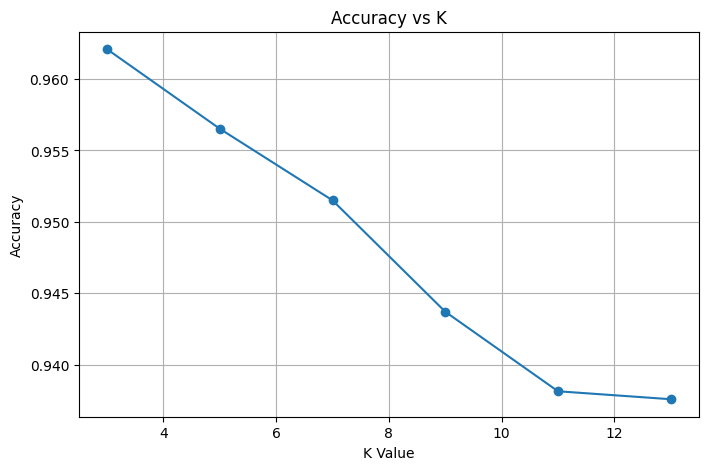

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(k, acc, marker='o')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('Accuracy vs K')
plt.grid(True)
plt.show()

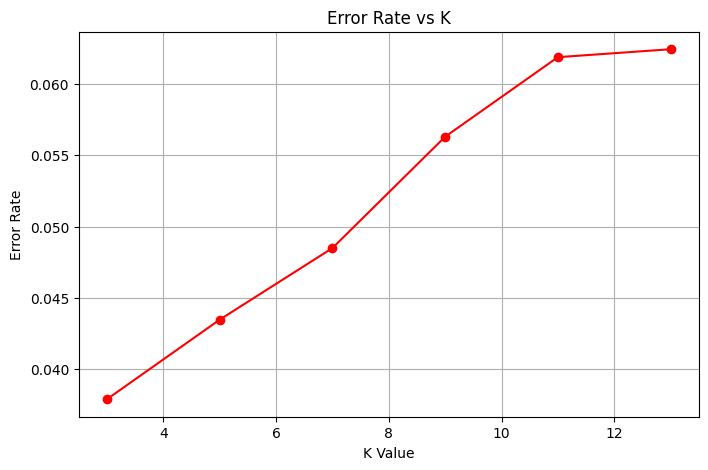

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(k, error_rate, marker='o', color='red')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.title('Error Rate vs K')
plt.grid(True)
plt.show()

In [ ]:
best_k = k[acc.index(max(acc))]
print("Best K =", best_k)

Best K = 3


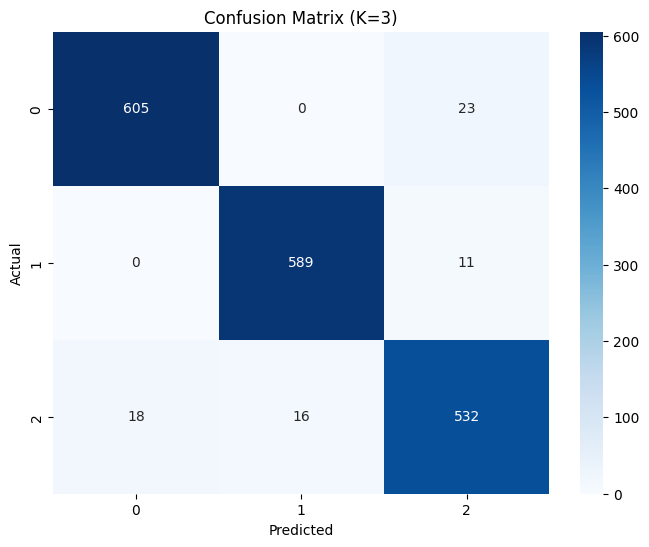

In [ ]:
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(x_train, y_train)

y_pred_best = best_knn.predict(x_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (K={best_k})')
plt.show()

In [ ]:
params={
    "kernel":['linear'],
     "C": [0.1, 1, 10],
    "gamma": ["scale", "auto"]
}
sv=SVC()
grid=GridSearchCV(sv,param_grid=params,cv=5)
grid.fit(x_train,y_train)
y_pred=grid.predict(x_test)
print(f"Accuracy: {accuracy_score(y_test,y_pred)}")
print(f"Precision: {precision_score(y_test,y_pred,average='weighted')}")
print(f"Recall: {recall_score(y_test,y_pred,average='weighted')}")
print(f"F1 Score: {f1_score(y_test,y_pred,average='weighted')}")

Accuracy: 0.9871794871794872
Precision: 0.987170986007394
Recall: 0.9871794871794872
F1 Score: 0.9871710872168226


In [ ]:
params={
    "kernel":['rbf'],
     "C": [0.1, 1, 10],
    "gamma": ["scale", "auto"]
}
sv=SVC()
grid=GridSearchCV(sv,param_grid=params,cv=5)
grid.fit(x_train,y_train)
y_pred=grid.predict(x_test)
print(f"Accuracy: {accuracy_score(y_test,y_pred)}")
print(f"Precision: {precision_score(y_test,y_pred,average='weighted')}")
print(f"Recall: {recall_score(y_test,y_pred,average='weighted')}")
print(f"F1 Score: {f1_score(y_test,y_pred,average='weighted')}")

Accuracy: 0.9793756967670011
Precision: 0.9793644059319548
Recall: 0.9793756967670011
F1 Score: 0.9793641943641839


In [ ]:
params={
    "kernel":['poly'],
     "C": [0.1, 1, 10],
    "gamma": ["scale", "auto"]
}
sv=SVC()
grid=GridSearchCV(sv,param_grid=params,cv=5)
grid.fit(x_train,y_train)
y_pred=grid.predict(x_test)
print(f"Accuracy: {accuracy_score(y_test,y_pred)}")
print(f"Precision: {precision_score(y_test,y_pred,average='weighted')}")
print(f"Recall: {recall_score(y_test,y_pred,average='weighted')}")
print(f"F1 Score: {f1_score(y_test,y_pred,average='weighted')}")

Accuracy: 0.9743589743589743
Precision: 0.9745342751326053
Recall: 0.9743589743589743
F1 Score: 0.9744053942886001


# Engineer 4 – Clustering Analysis

## Business Scenario

The organization wants to identify distinct supply-chain behavior groups to support strategic planning, resource allocation, and operational decision-making.

---

# Part A: K-Means Clustering

## Tasks

### 1. Data Preprocessing
- Standardize all numerical features using an appropriate scaling technique.
- Handle missing values and outliers if necessary.

### 2. Determine Optimal Number of Clusters

Use the following techniques:

#### Elbow Method
- Plot Within-Cluster Sum of Squares (WCSS) against the number of clusters.
- Identify the optimal K at the "elbow" point.

#### Silhouette Score Analysis
- Calculate silhouette scores for different values of K.
- Select the K value with the best cluster separation.

### 3. Cluster Formation
- Train the K-Means clustering model using the optimal K.
- Assign cluster labels to all observations.

---

## Deliverables

### Optimal Number of Clusters
- Report the selected K value.
- Justify the selection using evaluation metrics.

### Cluster Assignments
- Provide cluster labels for each observation.

---

# Part B: Hierarchical Clustering

## Tasks

### 1. Build Hierarchical Clustering Model
- Apply Agglomerative Hierarchical Clustering.
- Experiment with different linkage methods:
  - Ward
  - Complete
  - Average
  - Single

### 2. Generate Dendrogram
- Visualize hierarchical relationships between observations.
- Determine the appropriate number of clusters.

### 3. Cluster Formation
- Create clusters based on dendrogram analysis.

---

## Deliverables

### Dendrogram Analysis
- Interpret the dendrogram.
- Explain the selected cluster structure.

### Hierarchical Cluster Assignments
- Provide cluster labels for all observations.

---

# Part C: DBSCAN

## Tasks

### 1. Model Building
Train a DBSCAN clustering model.

### 2. Hyperparameter Tuning

Tune the following parameters:

- `eps`
- `min_samples`

### 3. Cluster Evaluation
- Identify core points, border points, and noise points.
- Compare clustering performance with K-Means and Hierarchical Clustering.

---

## Deliverables

### Optimal Parameters
- Report the best values of `eps` and `min_samples`.

### Noise Analysis
- Identify observations classified as outliers/noise.

### Cluster Quality Comparison
- Compare DBSCAN against other clustering methods.

---

# Evaluation Metrics

Evaluate all clustering approaches using:

- Silhouette Score
- Davies-Bouldin Index
- Calinski-Harabasz Score

---

# Visualizations

Create the following visualizations:

### Cluster Discovery
1. Elbow Method Plot
2. Silhouette Score Plot
3. Dendrogram

### Cluster Analysis
4. PCA-Based Cluster Visualization
5. Cluster Distribution Chart
6. Cluster Profile Charts

### DBSCAN Analysis
7. Noise Point Visualization
8. Cluster Density Visualization

---

# Deliverables

## Cluster Profiles
For each cluster, provide:

- Cluster Size
- Average Feature Values
- Key Characteristics
- Distinguishing Behaviors

## Segment Descriptions

Create business-friendly descriptions for each identified segment.

Example:

- Efficient Supply Chains
- High-Risk Supply Chains
- Cost-Optimized Operations
- Volatile Market Responders

## Business Recommendations

Provide actionable recommendations for:

- Inventory Management
- Pricing Strategies
- Supplier Optimization
- Demand Forecasting
- Risk Management

---

In [ ]:
supply_chain_df = df.copy(deep=True)

# Hell


In [ ]:
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 130

RANDOM_STATE = 42
TARGET_COL = "LBL"

output_dir = Path("tac_scm_clustering")
artifacts_dir = output_dir / "artifacts"
output_dir.mkdir(exist_ok=True, parents=True)
artifacts_dir.mkdir(exist_ok=True, parents=True)

In [ ]:
def safe_silhouette(X, labels):
    labels = np.asarray(labels)
    mask = labels != -1
    if mask.sum() < 2:
        return np.nan
    if len(np.unique(labels[mask])) < 2:
        return np.nan
    return silhouette_score(X[mask], labels[mask])

def safe_davies_bouldin(X, labels):
    labels = np.asarray(labels)
    mask = labels != -1
    if mask.sum() < 2 or len(np.unique(labels[mask])) < 2:
        return np.nan
    return davies_bouldin_score(X[mask], labels[mask])

def safe_calinski_harabasz(X, labels):
    labels = np.asarray(labels)
    mask = labels != -1
    if mask.sum() < 2 or len(np.unique(labels[mask])) < 2:
        return np.nan
    return calinski_harabasz_score(X[mask], labels[mask])

def clip_outliers_iqr(df, cols):
    out = df.copy()
    for c in cols:
        q1 = out[c].quantile(0.25)
        q3 = out[c].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        out[c] = out[c].clip(lower, upper)
    return out

def select_numeric_features(df, exclude=None):
    exclude = exclude or []
    return [c for c in df.columns if c not in exclude and pd.api.types.is_numeric_dtype(df[c])]

def top_variance_features(df, features, n=20):
    return df[features].var().sort_values(ascending=False).head(n).index.tolist()

In [ ]:
supply_chain_df = supply_chain_df.drop_duplicates().reset_index(drop=True)

features = select_numeric_features(supply_chain_df, exclude=[TARGET_COL])  # keep LBL out of clustering
X = supply_chain_df[features].copy()

imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=features, index=supply_chain_df.index)

X_clipped = clip_outliers_iqr(X_imputed, features)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clipped)

joblib.dump(imputer, artifacts_dir / "imputer.joblib")
joblib.dump(scaler, artifacts_dir / "scaler.joblib")

print("Prepared matrix:", X_scaled.shape)

Prepared matrix: (8966, 76)


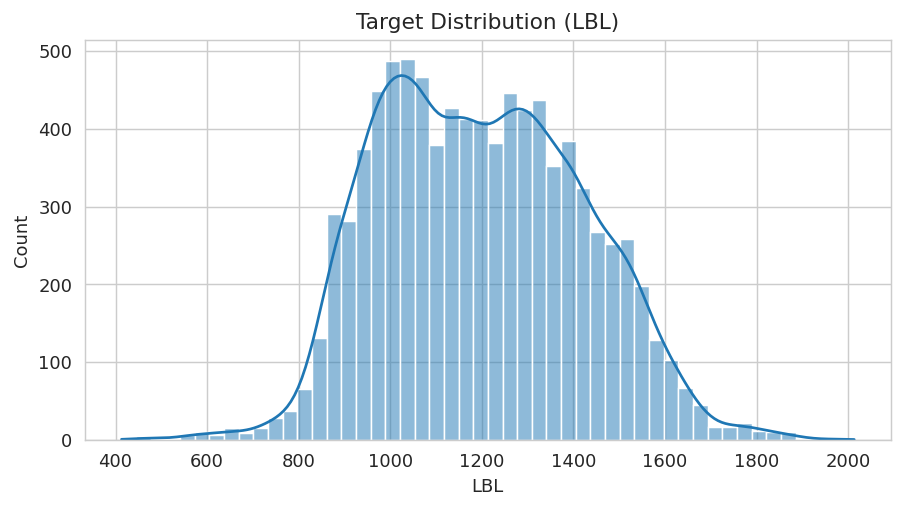

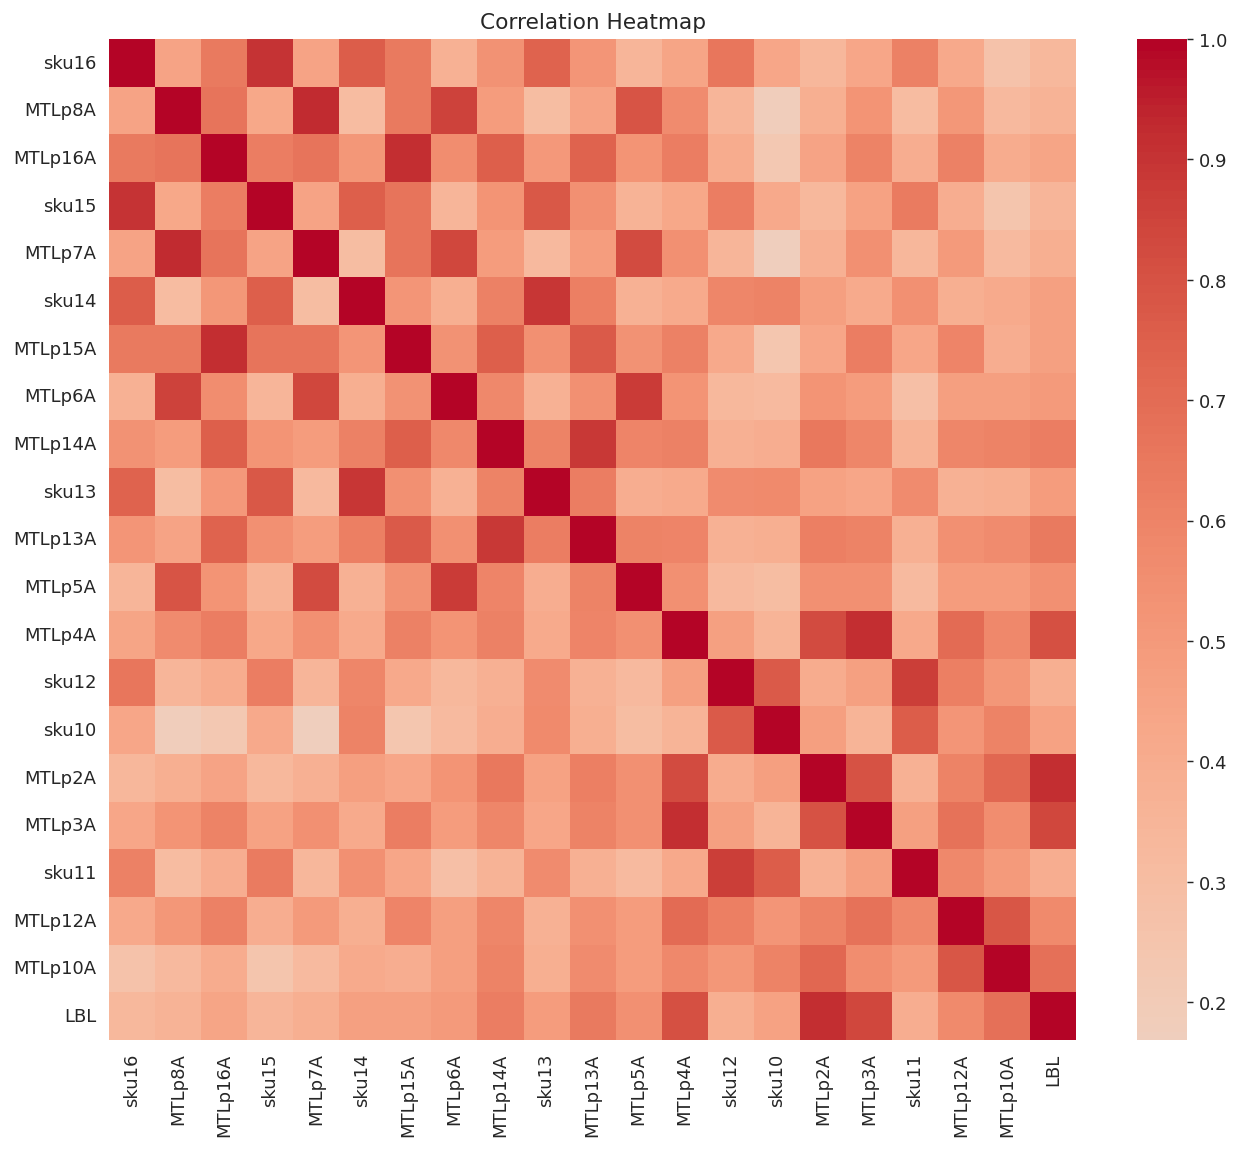

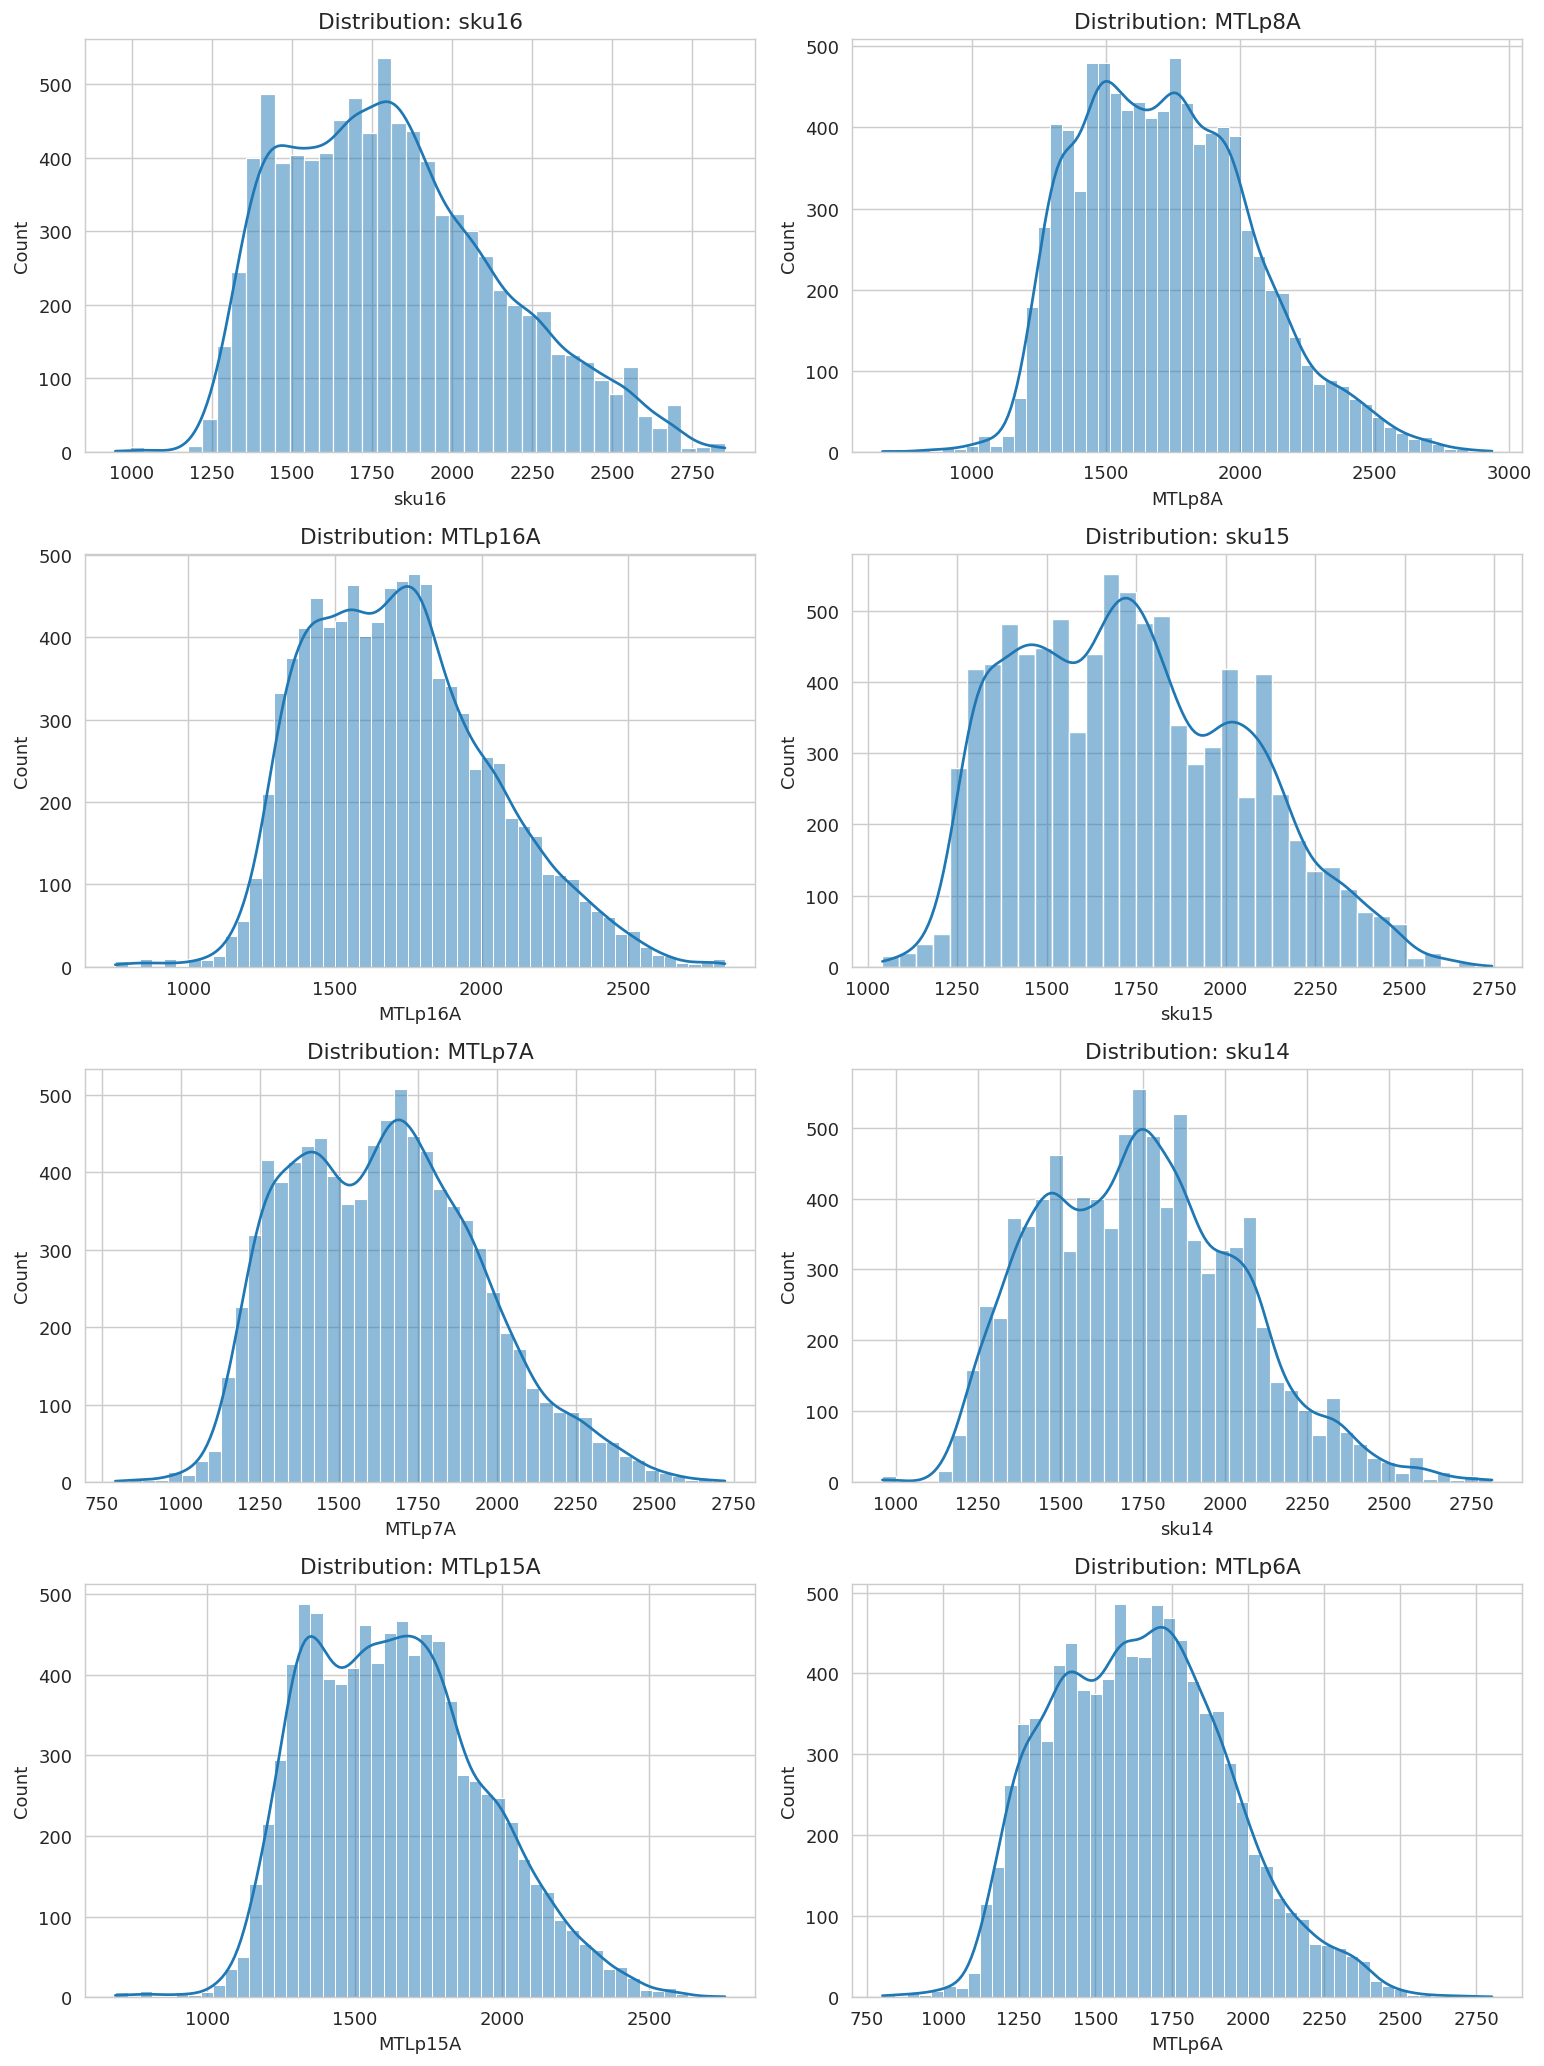

In [ ]:
# Target distribution
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(supply_chain_df[TARGET_COL], kde=True, ax=ax)
ax.set_title("Target Distribution (LBL)")
plt.show()

# Correlation heatmap of top variance features + target
heat_cols = top_variance_features(supply_chain_df, features + [TARGET_COL], n=20)
if TARGET_COL not in heat_cols:
    heat_cols = heat_cols + [TARGET_COL]
corr = supply_chain_df[heat_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Heatmap")
plt.show()

# Feature distributions
dist_cols = top_variance_features(supply_chain_df, features, n=8)
ncols = 2
nrows = int(np.ceil(len(dist_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
axes = np.array(axes).reshape(-1)

for i, c in enumerate(dist_cols):
    sns.histplot(supply_chain_df[c], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution: {c}")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

,k,inertia,silhouette
0,2,557263.897500,0.165368
1,3,510656.000265,0.154606
2,4,473599.512146,0.145127
3,5,445938.235661,0.143547
4,6,422687.592073,0.146937
5,7,406393.753702,0.135439
6,8,392726.833994,0.121198
7,9,381504.231659,0.114656
8,10,371697.182921,0.117944
9,11,363667.511489,0.114857


Best K: 2


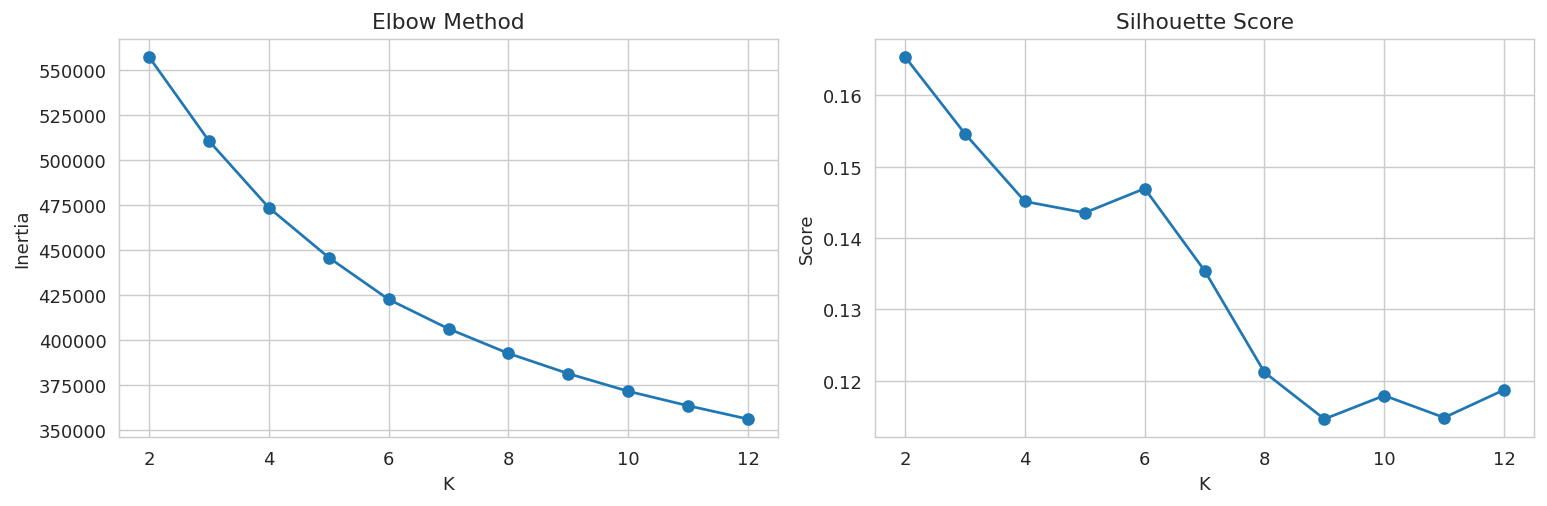

{'silhouette': np.float64(0.16536822657420733),
 'davies_bouldin': np.float64(2.059272996016986),
 'calinski_harabasz': np.float64(1997.078762824395)}

In [ ]:
k_values = range(2, 13)
inertias = []
silhouettes = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = model.fit_predict(X_scaled)
    inertias.append(model.inertia_)
    silhouettes.append(safe_silhouette(X_scaled, labels))

k_search = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette": silhouettes
})

display(k_search)

best_k = int(k_search.loc[k_search["silhouette"].idxmax(), "k"])
print("Best K:", best_k)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_search["k"], k_search["inertia"], marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")

axes[1].plot(k_search["k"], k_search["silhouette"], marker="o")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Score")
plt.tight_layout()
plt.show()

kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

kmeans_metrics = {
    "silhouette": safe_silhouette(X_scaled, kmeans_labels),
    "davies_bouldin": davies_bouldin_score(X_scaled, kmeans_labels),
    "calinski_harabasz": calinski_harabasz_score(X_scaled, kmeans_labels),
}
kmeans_metrics

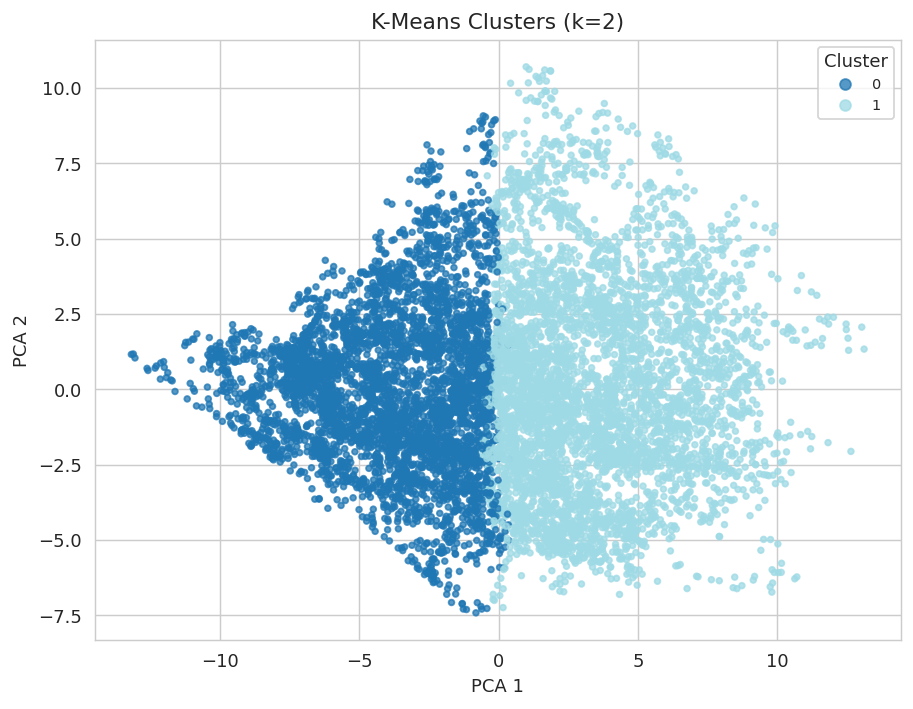

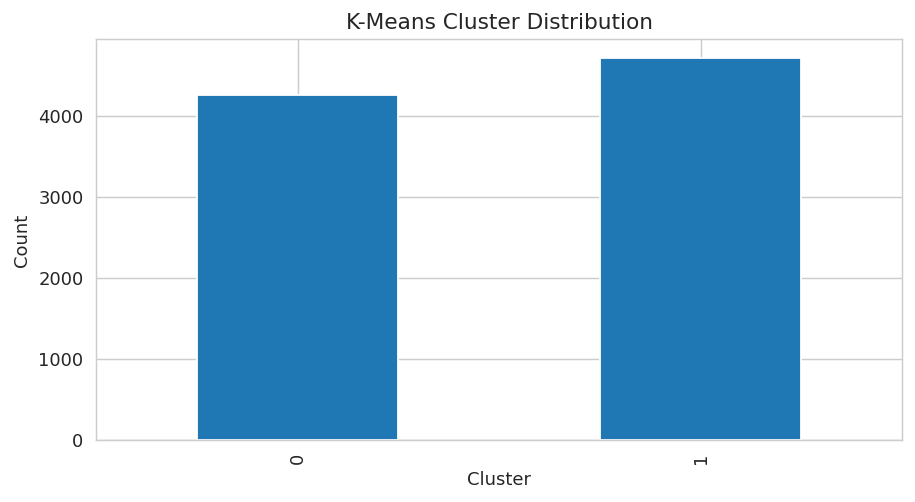

,timeunit,storageCost,interestRate,compidx0lt2,compidx4lt2,compidx6lt2,compidx8lt2,compidx10lt2,compidx12lt2,compidx14lt2,...,MTLp7A,MTLp8A,MTLp9A,MTLp10A,MTLp11A,MTLp12A,MTLp13A,MTLp14A,MTLp15A,MTLp16A
cluster,,,,,,,,,,,,,,,,,,,,,
0,123.728212,36.891473,9.058962,644.760739,162.205837,159.531555,66.511413,65.154928,187.525535,187.421863,...,1501.166079,1575.958656,1054.813953,1132.373033,1134.471224,1206.529011,1394.077519,1471.893352,1476.643881,1558.925769
1,83.600977,36.359312,8.863028,795.576781,188.894999,183.186159,91.155929,88.198596,214.391138,216.942966,...,1776.923975,1858.203016,1302.339138,1392.441495,1384.514971,1472.694203,1719.641750,1808.894670,1790.024634,1868.363347


In [ ]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X2 = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X2[:, 0], X2[:, 1], c=kmeans_labels, s=10, cmap="tab20", alpha=0.75)
ax.set_title(f"K-Means Clusters (k={best_k})")
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.legend(*scatter.legend_elements(), title="Cluster", loc="best", fontsize=8)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
pd.Series(kmeans_labels).value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_title("K-Means Cluster Distribution")
ax.set_xlabel("Cluster")
ax.set_ylabel("Count")
plt.show()

kmeans_profile = df[features].copy()
kmeans_profile["cluster"] = kmeans_labels
kmeans_profile = kmeans_profile.groupby("cluster").mean(numeric_only=True)

display(kmeans_profile)

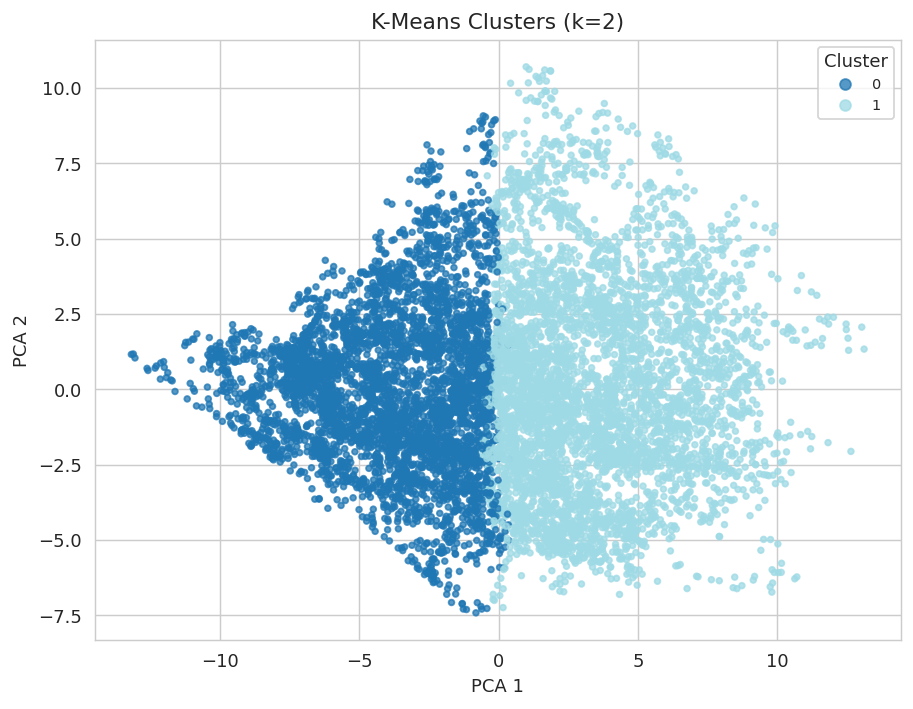

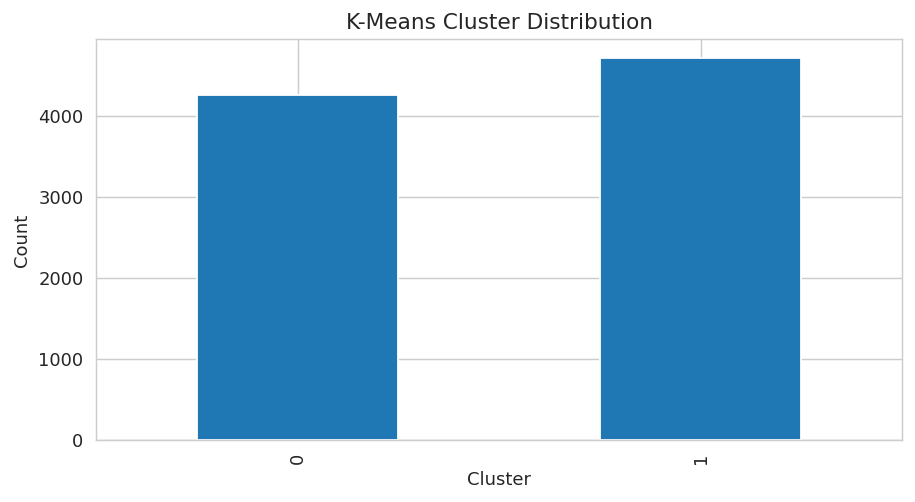

,timeunit,storageCost,interestRate,compidx0lt2,compidx4lt2,compidx6lt2,compidx8lt2,compidx10lt2,compidx12lt2,compidx14lt2,...,MTLp7A,MTLp8A,MTLp9A,MTLp10A,MTLp11A,MTLp12A,MTLp13A,MTLp14A,MTLp15A,MTLp16A
cluster,,,,,,,,,,,,,,,,,,,,,
0,123.728212,36.891473,9.058962,644.760739,162.205837,159.531555,66.511413,65.154928,187.525535,187.421863,...,1501.166079,1575.958656,1054.813953,1132.373033,1134.471224,1206.529011,1394.077519,1471.893352,1476.643881,1558.925769
1,83.600977,36.359312,8.863028,795.576781,188.894999,183.186159,91.155929,88.198596,214.391138,216.942966,...,1776.923975,1858.203016,1302.339138,1392.441495,1384.514971,1472.694203,1719.641750,1808.894670,1790.024634,1868.363347


In [ ]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X2 = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X2[:, 0], X2[:, 1], c=kmeans_labels, s=10, cmap="tab20", alpha=0.75)
ax.set_title(f"K-Means Clusters (k={best_k})")
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.legend(*scatter.legend_elements(), title="Cluster", loc="best", fontsize=8)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
pd.Series(kmeans_labels).value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_title("K-Means Cluster Distribution")
ax.set_xlabel("Cluster")
ax.set_ylabel("Count")
plt.show()

kmeans_profile = df[features].copy()
kmeans_profile["cluster"] = kmeans_labels
kmeans_profile = kmeans_profile.groupby("cluster").mean(numeric_only=True)

display(kmeans_profile)

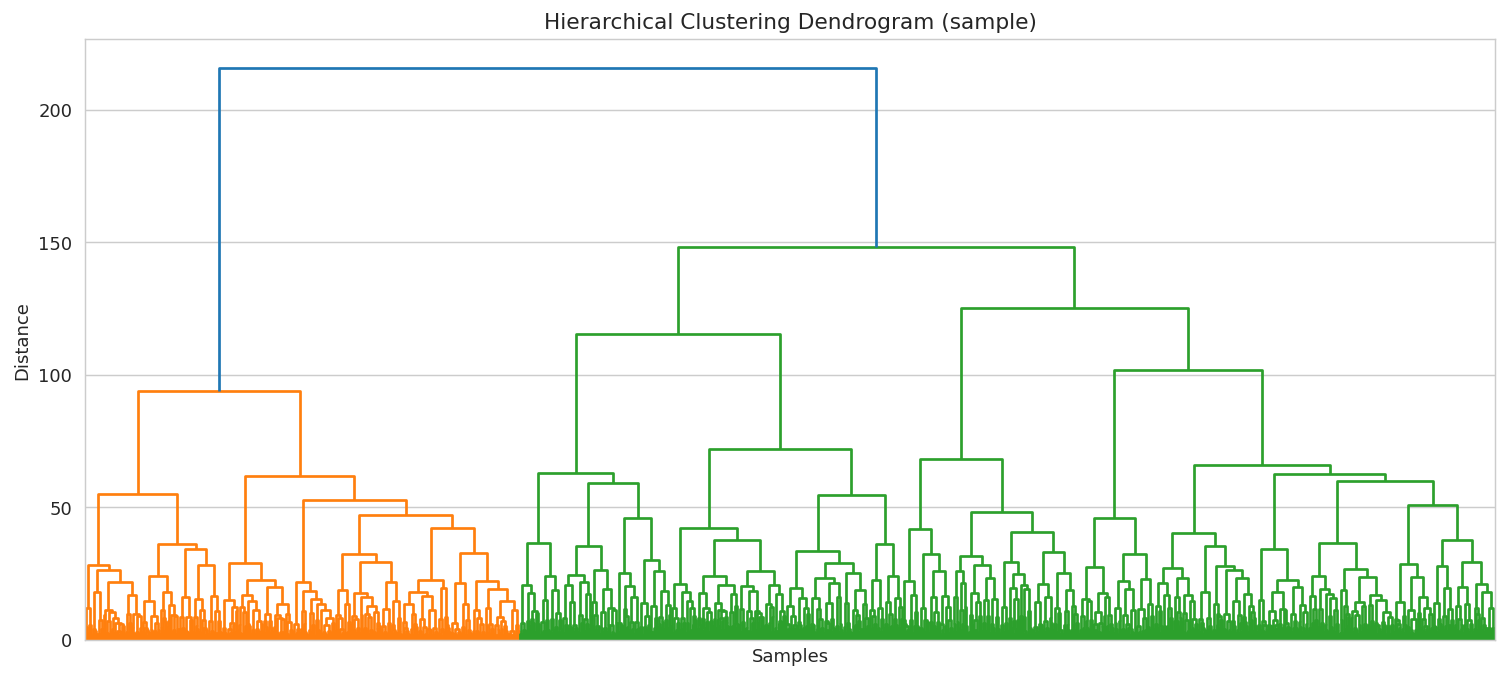

,k,silhouette
0,2,0.126923
1,3,0.106800
2,4,0.119348
3,5,0.124749
4,6,0.129740
5,7,0.105730
6,8,0.096569
7,9,0.100088
8,10,0.097358
9,11,0.102164


{'silhouette': np.float64(0.12973972178877757),
 'davies_bouldin': np.float64(1.986114543131591),
 'calinski_harabasz': np.float64(216.09083654242318)}

In [ ]:
sample_size = min(2000, len(supply_chain_df))
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(supply_chain_df), size=sample_size, replace=False)
X_sample = X_scaled[sample_idx]

Z = linkage(X_sample, method="ward")

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, ax=ax, no_labels=True)
ax.set_title("Hierarchical Clustering Dendrogram (sample)")
ax.set_xlabel("Samples")
ax.set_ylabel("Distance")
plt.show()

# try a few k values on the sample
h_scores = []
h_models = []
for k in range(2, 13):
    try:
        try:
            model = AgglomerativeClustering(n_clusters=k, linkage="ward", metric="euclidean")
        except TypeError:
            model = AgglomerativeClustering(n_clusters=k, linkage="ward")
        labels = model.fit_predict(X_sample)
        h_scores.append(safe_silhouette(X_sample, labels))
        h_models.append((k, labels))
    except Exception:
        h_scores.append(np.nan)
        h_models.append((k, None))

h_search = pd.DataFrame({
    "k": list(range(2, 13)),
    "silhouette": h_scores
})
display(h_search)

best_h_k = int(h_search.loc[h_search["silhouette"].idxmax(), "k"])
hier_labels = dict(h_models)[best_h_k]

hier_metrics = {
    "silhouette": safe_silhouette(X_sample, hier_labels),
    "davies_bouldin": safe_davies_bouldin(X_sample, hier_labels),
    "calinski_harabasz": safe_calinski_harabasz(X_sample, hier_labels),
}
hier_metrics

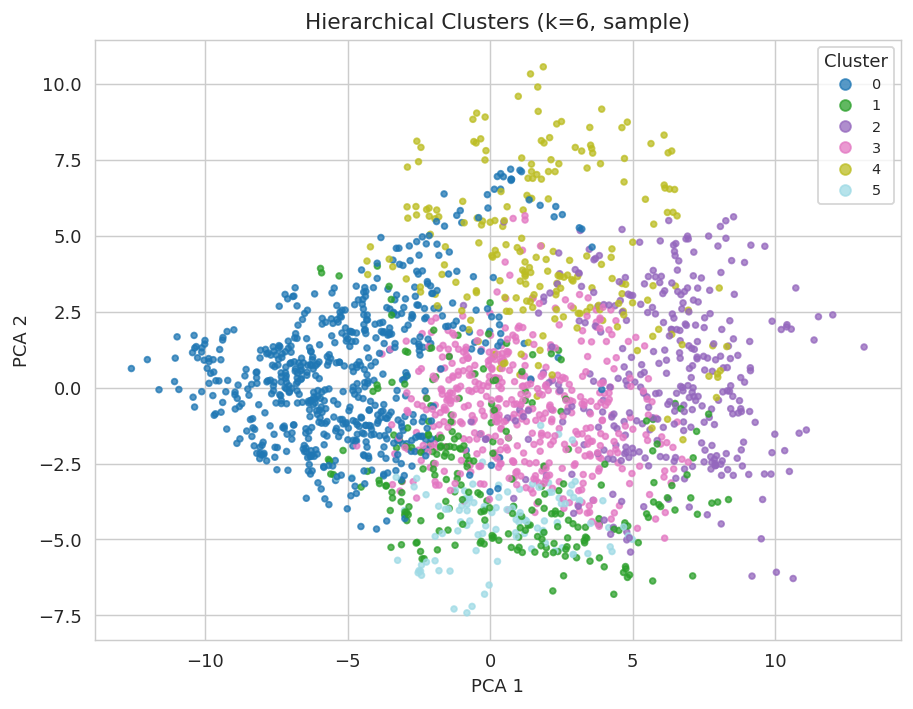

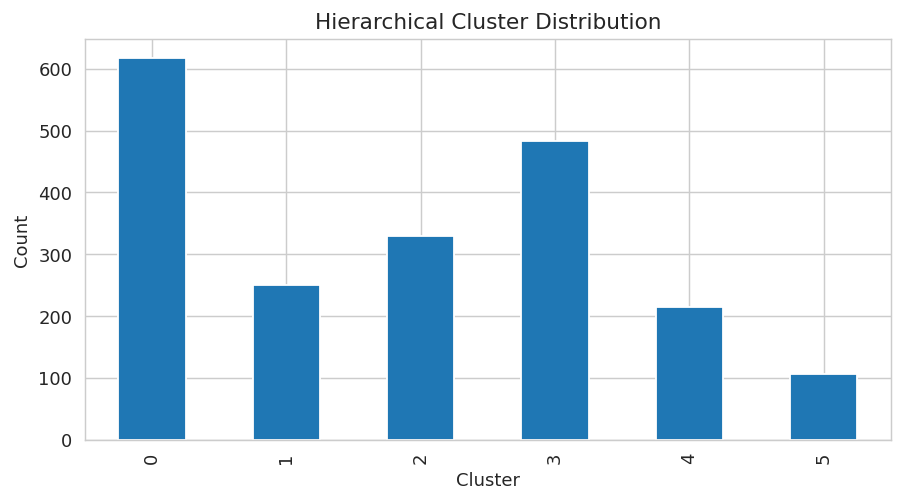

,timeunit,storageCost,interestRate,compidx0lt2,compidx4lt2,compidx6lt2,compidx8lt2,compidx10lt2,compidx12lt2,compidx14lt2,...,MTLp7A,MTLp8A,MTLp9A,MTLp10A,MTLp11A,MTLp12A,MTLp13A,MTLp14A,MTLp15A,MTLp16A
cluster,,,,,,,,,,,,,,,,,,,,,
0,127.625608,36.233387,9.249595,677.520412,148.718308,149.278335,64.362146,63.214102,180.180849,175.926648,...,1459.938412,1527.855754,1010.975689,1079.486224,1083.105348,1151.212318,1340.153971,1410.398703,1417.486224,1489.533225
1,96.504000,33.860000,8.908000,629.172196,296.989436,257.246688,71.569164,64.560896,211.353704,202.560340,...,1630.316000,1724.912000,1099.276000,1191.276000,1201.548000,1292.072000,1548.796000,1652.720000,1667.124000,1759.364000
2,39.082067,34.082067,8.765957,866.257854,204.309195,203.324216,106.569736,100.599255,238.392146,235.296976,...,1796.632219,1872.306991,1348.650456,1447.623100,1428.996960,1529.355623,1748.544073,1828.069909,1800.705167,1863.641337
3,102.481405,39.855372,8.840909,804.244343,150.846157,154.446465,62.530339,61.138781,180.558711,179.623616,...,1780.055785,1872.214876,1249.415289,1348.857438,1379.458678,1491.256198,1690.076446,1791.264463,1820.266529,1930.070248
4,122.018692,32.574766,8.822430,658.996486,144.928533,142.971640,137.101678,139.878019,192.014322,208.290645,...,1612.761682,1676.742991,1321.700935,1433.261682,1290.247664,1375.901869,1617.742991,1728.775701,1533.406542,1610.140187
5,107.622642,42.801887,8.292453,611.916047,143.720302,150.991660,56.324736,55.737679,336.127330,373.228491,...,1853.301887,1830.877358,1195.867925,1180.443396,1372.924528,1321.849057,1616.103774,1617.716981,1858.301887,1861.066038


In [ ]:
X2_sample = X2[sample_idx]

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X2_sample[:, 0], X2_sample[:, 1], c=hier_labels, s=10, cmap="tab20", alpha=0.75)
ax.set_title(f"Hierarchical Clusters (k={best_h_k}, sample)")
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.legend(*scatter.legend_elements(), title="Cluster", loc="best", fontsize=8)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
pd.Series(hier_labels).value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_title("Hierarchical Cluster Distribution")
ax.set_xlabel("Cluster")
ax.set_ylabel("Count")
plt.show()

hier_df = supply_chain_df.iloc[sample_idx].copy()
hier_df["cluster"] = hier_labels
hier_profile = hier_df.groupby("cluster").mean(numeric_only=True)

display(hier_profile)

In [ ]:
# DBSCAN works better in lower-dimensional space
pca_db = PCA(n_components=min(10, X_scaled.shape[1]), random_state=RANDOM_STATE)
X_db = pca_db.fit_transform(X_scaled)

nbrs = NearestNeighbors(n_neighbors=6)
nbrs.fit(X_db)
distances, _ = nbrs.kneighbors(X_db)
kth_distances = np.sort(distances[:, -1])

eps_candidates = np.unique(np.quantile(kth_distances, [0.70, 0.75, 0.80, 0.85, 0.90, 0.95]))
min_samples_candidates = [3, 5, 8, 10, 15]

db_rows = []
best_db = None

for eps in eps_candidates:
    for min_samples in min_samples_candidates:
        model = DBSCAN(eps=float(eps), min_samples=int(min_samples))
        labels = model.fit_predict(X_db)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_ratio = float(np.mean(labels == -1))
        sil = safe_silhouette(X_db, labels)
        dbi = safe_davies_bouldin(X_db, labels)
        chi = safe_calinski_harabasz(X_db, labels)

        db_rows.append({
            "eps": float(eps),
            "min_samples": int(min_samples),
            "n_clusters": int(n_clusters),
            "noise_ratio": noise_ratio,
            "silhouette": sil,
            "davies_bouldin": dbi,
            "calinski_harabasz": chi,
        })

        valid = (n_clusters >= 2) and (noise_ratio < 0.95) and not np.isnan(sil)
        if valid:
            score_tuple = (sil, -dbi if not np.isnan(dbi) else -np.inf, chi if not np.isnan(chi) else -np.inf)
            if best_db is None or score_tuple > best_db["score_tuple"]:
                best_db = {
                    "labels": labels,
                    "eps": float(eps),
                    "min_samples": int(min_samples),
                    "score_tuple": score_tuple,
                    "metrics": {
                        "silhouette": sil,
                        "davies_bouldin": dbi,
                        "calinski_harabasz": chi,
                        "noise_ratio": noise_ratio,
                        "n_clusters": int(n_clusters),
                    },
                }

db_search = pd.DataFrame(db_rows).sort_values(
    by=["silhouette", "calinski_harabasz"],
    ascending=[False, False],
    na_position="last"
)

display(db_search.head(10))
best_db

,eps,min_samples,n_clusters,noise_ratio,silhouette,davies_bouldin,calinski_harabasz
9,1.642824,15,77,0.745148,0.485154,0.698805,544.320027
4,1.568795,15,68,0.787308,0.481299,0.700842,557.214570
14,1.733385,15,97,0.672541,0.395377,0.821790,358.992545
3,1.568795,10,207,0.448249,0.357652,0.822718,279.283251
8,1.642824,10,217,0.380103,0.315823,0.867979,255.531539
19,1.855494,15,114,0.572050,0.281423,0.830566,211.487975
2,1.568795,8,264,0.277939,0.258277,0.922426,176.500228
13,1.733385,10,218,0.303368,0.244564,0.913929,189.210971
24,2.028851,15,130,0.422039,0.235520,0.894411,212.331227
7,1.642824,8,241,0.236672,0.199994,1.002282,150.544531


{'labels': array([ 0,  0,  0, ..., -1, -1, -1]),
 'eps': 1.642823579692077,
 'min_samples': 15,
 'score_tuple': (np.float64(0.4851542296270884),
  np.float64(-0.6988049817452995),
  np.float64(544.3200269300842)),
 'metrics': {'silhouette': np.float64(0.4851542296270884),
  'davies_bouldin': np.float64(0.6988049817452995),
  'calinski_harabasz': np.float64(544.3200269300842),
  'noise_ratio': 0.7451483381664065,
  'n_clusters': 77}}

Best DBSCAN params: 1.642823579692077 15
{'silhouette': np.float64(0.4851542296270884), 'davies_bouldin': np.float64(0.6988049817452995), 'calinski_harabasz': np.float64(544.3200269300842), 'noise_ratio': 0.7451483381664065, 'n_clusters': 77}


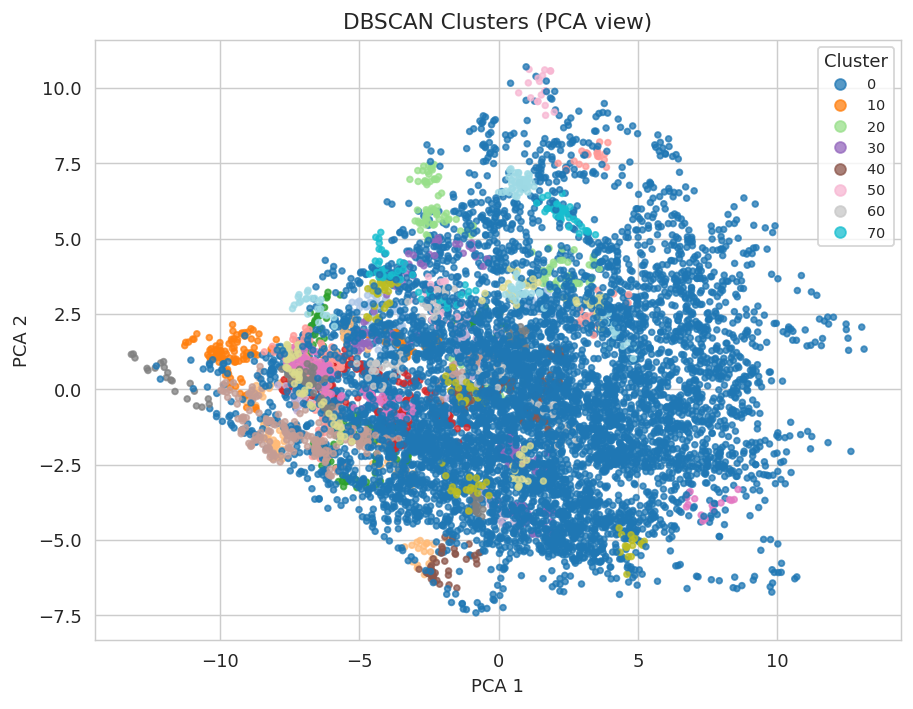

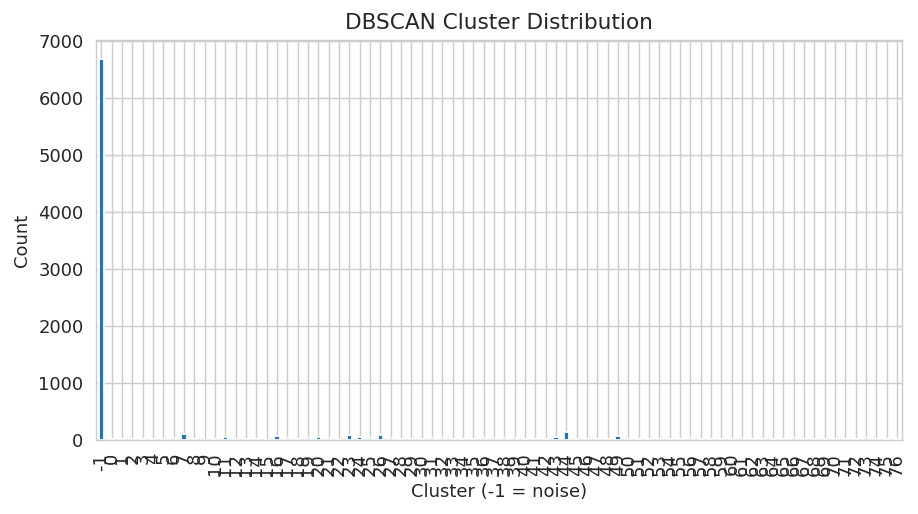

,timeunit,storageCost,interestRate,compidx0lt2,compidx4lt2,compidx6lt2,compidx8lt2,compidx10lt2,compidx12lt2,compidx14lt2,...,MTLp7A,MTLp8A,MTLp9A,MTLp10A,MTLp11A,MTLp12A,MTLp13A,MTLp14A,MTLp15A,MTLp16A
cluster,,,,,,,,,,,,,,,,,,,,,
0,16.000000,27.0,8.0,847.241400,280.968133,266.052733,115.822000,110.189400,255.180733,214.559867,...,1745.533333,1871.466667,1323.533333,1423.466667,1332.266667,1442.133333,1811.466667,1942.333333,1654.133333,1631.800000
1,90.000000,27.0,8.0,807.930870,175.311522,143.581043,114.564652,110.839304,229.790391,167.281391,...,1250.956522,1333.391304,950.347826,1062.086957,980.913043,1075.652174,1216.217391,1319.043478,1255.434783,1344.043478
2,112.000000,27.0,8.0,776.199905,169.749524,143.860667,95.728714,83.811143,232.655762,168.136238,...,1293.238095,1381.619048,987.238095,1076.809524,1027.809524,1104.714286,1288.809524,1347.809524,1296.428571,1450.380952
3,177.545455,27.0,8.0,586.884591,195.458636,149.689500,100.832727,61.815091,182.596955,185.140773,...,1582.500000,1765.954545,1345.772727,1452.909091,1431.727273,1528.000000,1737.045455,1805.863636,1672.681818,1825.681818
4,133.040000,29.0,8.0,608.945800,218.486800,217.012680,86.223000,59.273360,225.978360,170.152960,...,1303.720000,1361.800000,898.480000,951.720000,987.960000,1044.600000,1136.320000,1189.000000,1225.960000,1265.440000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,85.263158,27.0,11.0,1068.693474,140.885947,137.381000,112.767737,111.797158,249.002789,176.982947,...,1511.000000,1566.052632,1144.421053,1228.736842,1096.052632,1167.526316,1688.842105,1763.526316,1461.052632,1562.894737
73,121.000000,27.0,11.0,1034.651930,141.661419,141.763023,110.223209,111.113651,169.554698,168.940395,...,1484.000000,1558.651163,1303.767442,1363.930233,1322.976744,1326.139535,1499.023256,1519.511628,1428.813953,1518.930233
74,182.500000,27.0,11.0,862.124636,144.907455,143.990818,74.915318,86.800364,172.267045,176.651136,...,1273.000000,1331.409091,949.727273,1046.409091,1037.318182,1104.363636,1209.772727,1259.681818,1270.636364,1315.727273


In [ ]:
if best_db is not None:
    db_labels = best_db["labels"]
    print("Best DBSCAN params:", best_db["eps"], best_db["min_samples"])
    print(best_db["metrics"])

    fig, ax = plt.subplots(figsize=(8, 6))
    scatter = ax.scatter(X2[:, 0], X2[:, 1], c=db_labels, s=10, cmap="tab20", alpha=0.75)
    ax.set_title("DBSCAN Clusters (PCA view)")
    ax.set_xlabel("PCA 1")
    ax.set_ylabel("PCA 2")
    ax.legend(*scatter.legend_elements(), title="Cluster", loc="best", fontsize=8)
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 4))
    pd.Series(db_labels).value_counts().sort_index().plot(kind="bar", ax=ax)
    ax.set_title("DBSCAN Cluster Distribution")
    ax.set_xlabel("Cluster (-1 = noise)")
    ax.set_ylabel("Count")
    plt.show()

    non_noise_mask = db_labels != -1
    if non_noise_mask.sum() > 0 and len(np.unique(db_labels[non_noise_mask])) > 1:
        db_df = df.loc[non_noise_mask].copy()
        db_df["cluster"] = db_labels[non_noise_mask]
        db_profile = db_df.groupby("cluster").mean(numeric_only=True)
        display(db_profile)
else:
    print("DBSCAN did not find a good clustering configuration.")

In [ ]:
comparison = pd.DataFrame([
    {
        "method": "K-Means",
        "n_clusters": best_k,
        "silhouette": kmeans_metrics["silhouette"],
        "davies_bouldin": kmeans_metrics["davies_bouldin"],
        "calinski_harabasz": kmeans_metrics["calinski_harabasz"],
        "noise_ratio": 0.0,
    },
    {
        "method": "Hierarchical",
        "n_clusters": best_h_k,
        "silhouette": hier_metrics["silhouette"],
        "davies_bouldin": hier_metrics["davies_bouldin"],
        "calinski_harabasz": hier_metrics["calinski_harabasz"],
        "noise_ratio": 0.0,
    },
])

if best_db is not None:
    comparison = pd.concat([comparison, pd.DataFrame([{
        "method": "DBSCAN",
        "n_clusters": best_db["metrics"]["n_clusters"],
        "silhouette": best_db["metrics"]["silhouette"],
        "davies_bouldin": best_db["metrics"]["davies_bouldin"],
        "calinski_harabasz": best_db["metrics"]["calinski_harabasz"],
        "noise_ratio": best_db["metrics"]["noise_ratio"],
    }])], ignore_index=True)

display(comparison)
comparison.to_csv(output_dir / "cluster_method_comparison.csv", index=False)

,method,n_clusters,silhouette,davies_bouldin,calinski_harabasz,noise_ratio
0,K-Means,2,0.165368,2.059273,1997.078763,0.000000
1,Hierarchical,6,0.129740,1.986115,216.090837,0.000000
2,DBSCAN,77,0.485154,0.698805,544.320027,0.745148



# Bonus Challenge (Entire Team)

## Ensemble Classification Model

Build an ensemble model using:

- Logistic Regression
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)

using:

```python
VotingClassifier

In [ ]:
from sklearn.ensemble import VotingClassifier

df_ens = df.copy()
med = df_ens['LBL'].median()
df_ens['target'] = (df_ens['LBL'] > med).astype(int)

X_ensemble = df_ens.drop(['LBL', 'target'], axis=1)
y_ensemble = df_ens['target']

X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(X_ensemble, y_ensemble, test_size=0.2, random_state=42)


scaler_v = StandardScaler()
X_train_v_scaled = scaler_v.fit_transform(X_train_v)
X_test_v_scaled = scaler_v.transform(X_test_v)


clf_lr = LogisticRegression(solver='liblinear', C=1.0, random_state=42)
clf_knn = KNeighborsClassifier(n_neighbors=5)
clf_svc = SVC(probability=True, kernel='rbf', C=1.0, random_state=42)

voting_model = VotingClassifier(
    estimators=[('lr', clf_lr), ('knn', clf_knn), ('svc', clf_svc)],
    voting='soft'
)

voting_model.fit(X_train_v_scaled, y_train_v)
y_pred_v = voting_model.predict(X_test_v_scaled)


print('===== Ensemble Voting Classifier Metrics =====')
print(f'Accuracy: {accuracy_score(y_test_v, y_pred_v):.4f}')
print(f'F1 Score: {f1_score(y_test_v, y_pred_v):.4f}')
print('\nClassification Report:')
print(classification_report(y_test_v, y_pred_v))

===== Ensemble Voting Classifier Metrics =====
Accuracy: 0.9654
F1 Score: 0.9653

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       900
           1       0.97      0.96      0.97       894

    accuracy                           0.97      1794
   macro avg       0.97      0.97      0.97      1794
weighted avg       0.97      0.97      0.97      1794



<Figure size 600x400 with 0 Axes>

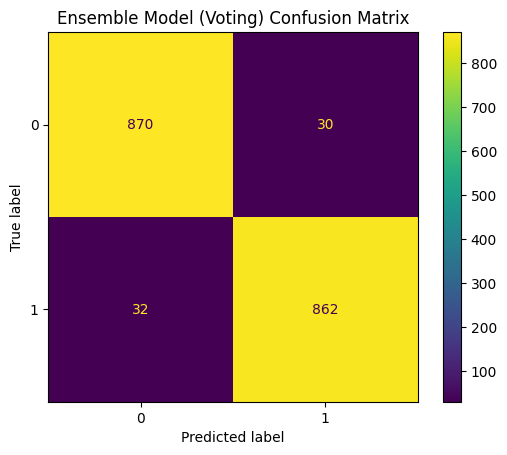

In [ ]:

plt.figure(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(y_test_v, y_pred_v, cmap='viridis')
plt.title('Ensemble Model (Voting) Confusion Matrix')
plt.show()